In [38]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy
import seaborn as sb
import src.concept_utils as cu


import matplotlib.pyplot as plt
import random as rd
import pickle as pkl
import scipy.special as sc
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
sys.path.append(os.getcwd())

In [39]:
sys.path.append(os.getcwd())

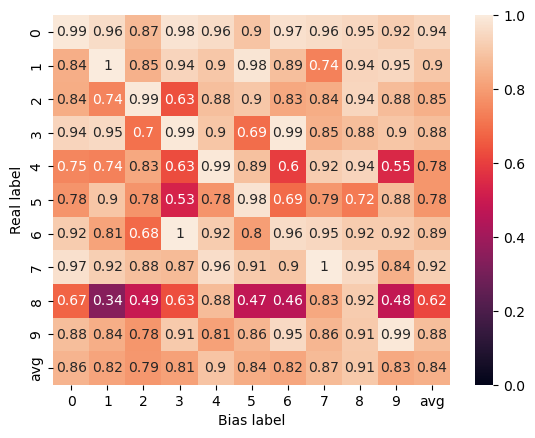

In [133]:
exp_id = 11
exp_name = "MNIST"
with open("/data/4vitry/models/" + exp_name + "/model_" + str(exp_id) + ".pkl", "rb") as f:
    model_res = pkl.load(f)
stat = model_res["correctness_matrix"]/model_res["appearance_matrix"]
stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=1)).T), axis =1)
stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=0))), axis =0)
ax = sb.heatmap(stat, vmin=0, vmax=1, annot=True, xticklabels=list(range(10)) + ["avg"], yticklabels=list(range(10)) + ["avg"])
ax.set(xlabel="Bias label", ylabel="Real label")
plt.show()

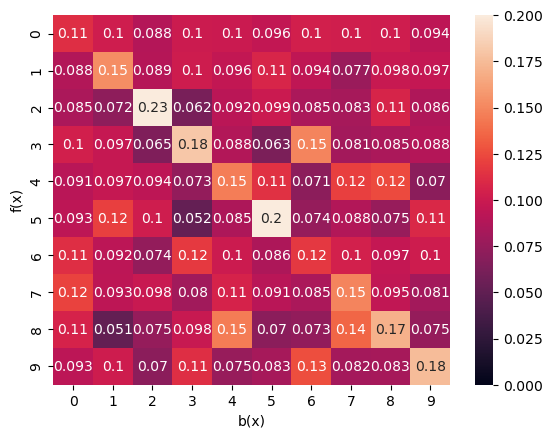

In [134]:
exp_id = 11
exp_name = "MNIST"
with open("/data/4vitry/models/" + exp_name + "/test_model_" + str(exp_id) + ".pkl", "rb") as f:
    stat = np.array(pkl.load(f))
"""P(b(x)|f(x))"""
label_sum = stat.sum(axis=1)
stat = (stat.T / label_sum).T
# """P(f(x)|b(x))"""
# label_sum = stat.sum(axis=0)
# stat = stat / label_sum
ax = sb.heatmap(stat, vmin=0, vmax=0.2, annot=True, xticklabels=list(range(10)), yticklabels=list(range(10)))
ax.set(xlabel="b(x)", ylabel="f(x)")
plt.show()

For 16 concept, the vector similarity is : [0.         0.00267834 0.00678755 0.04805844 0.02886552 0.1397234
 0.20974888 0.2468053 ]


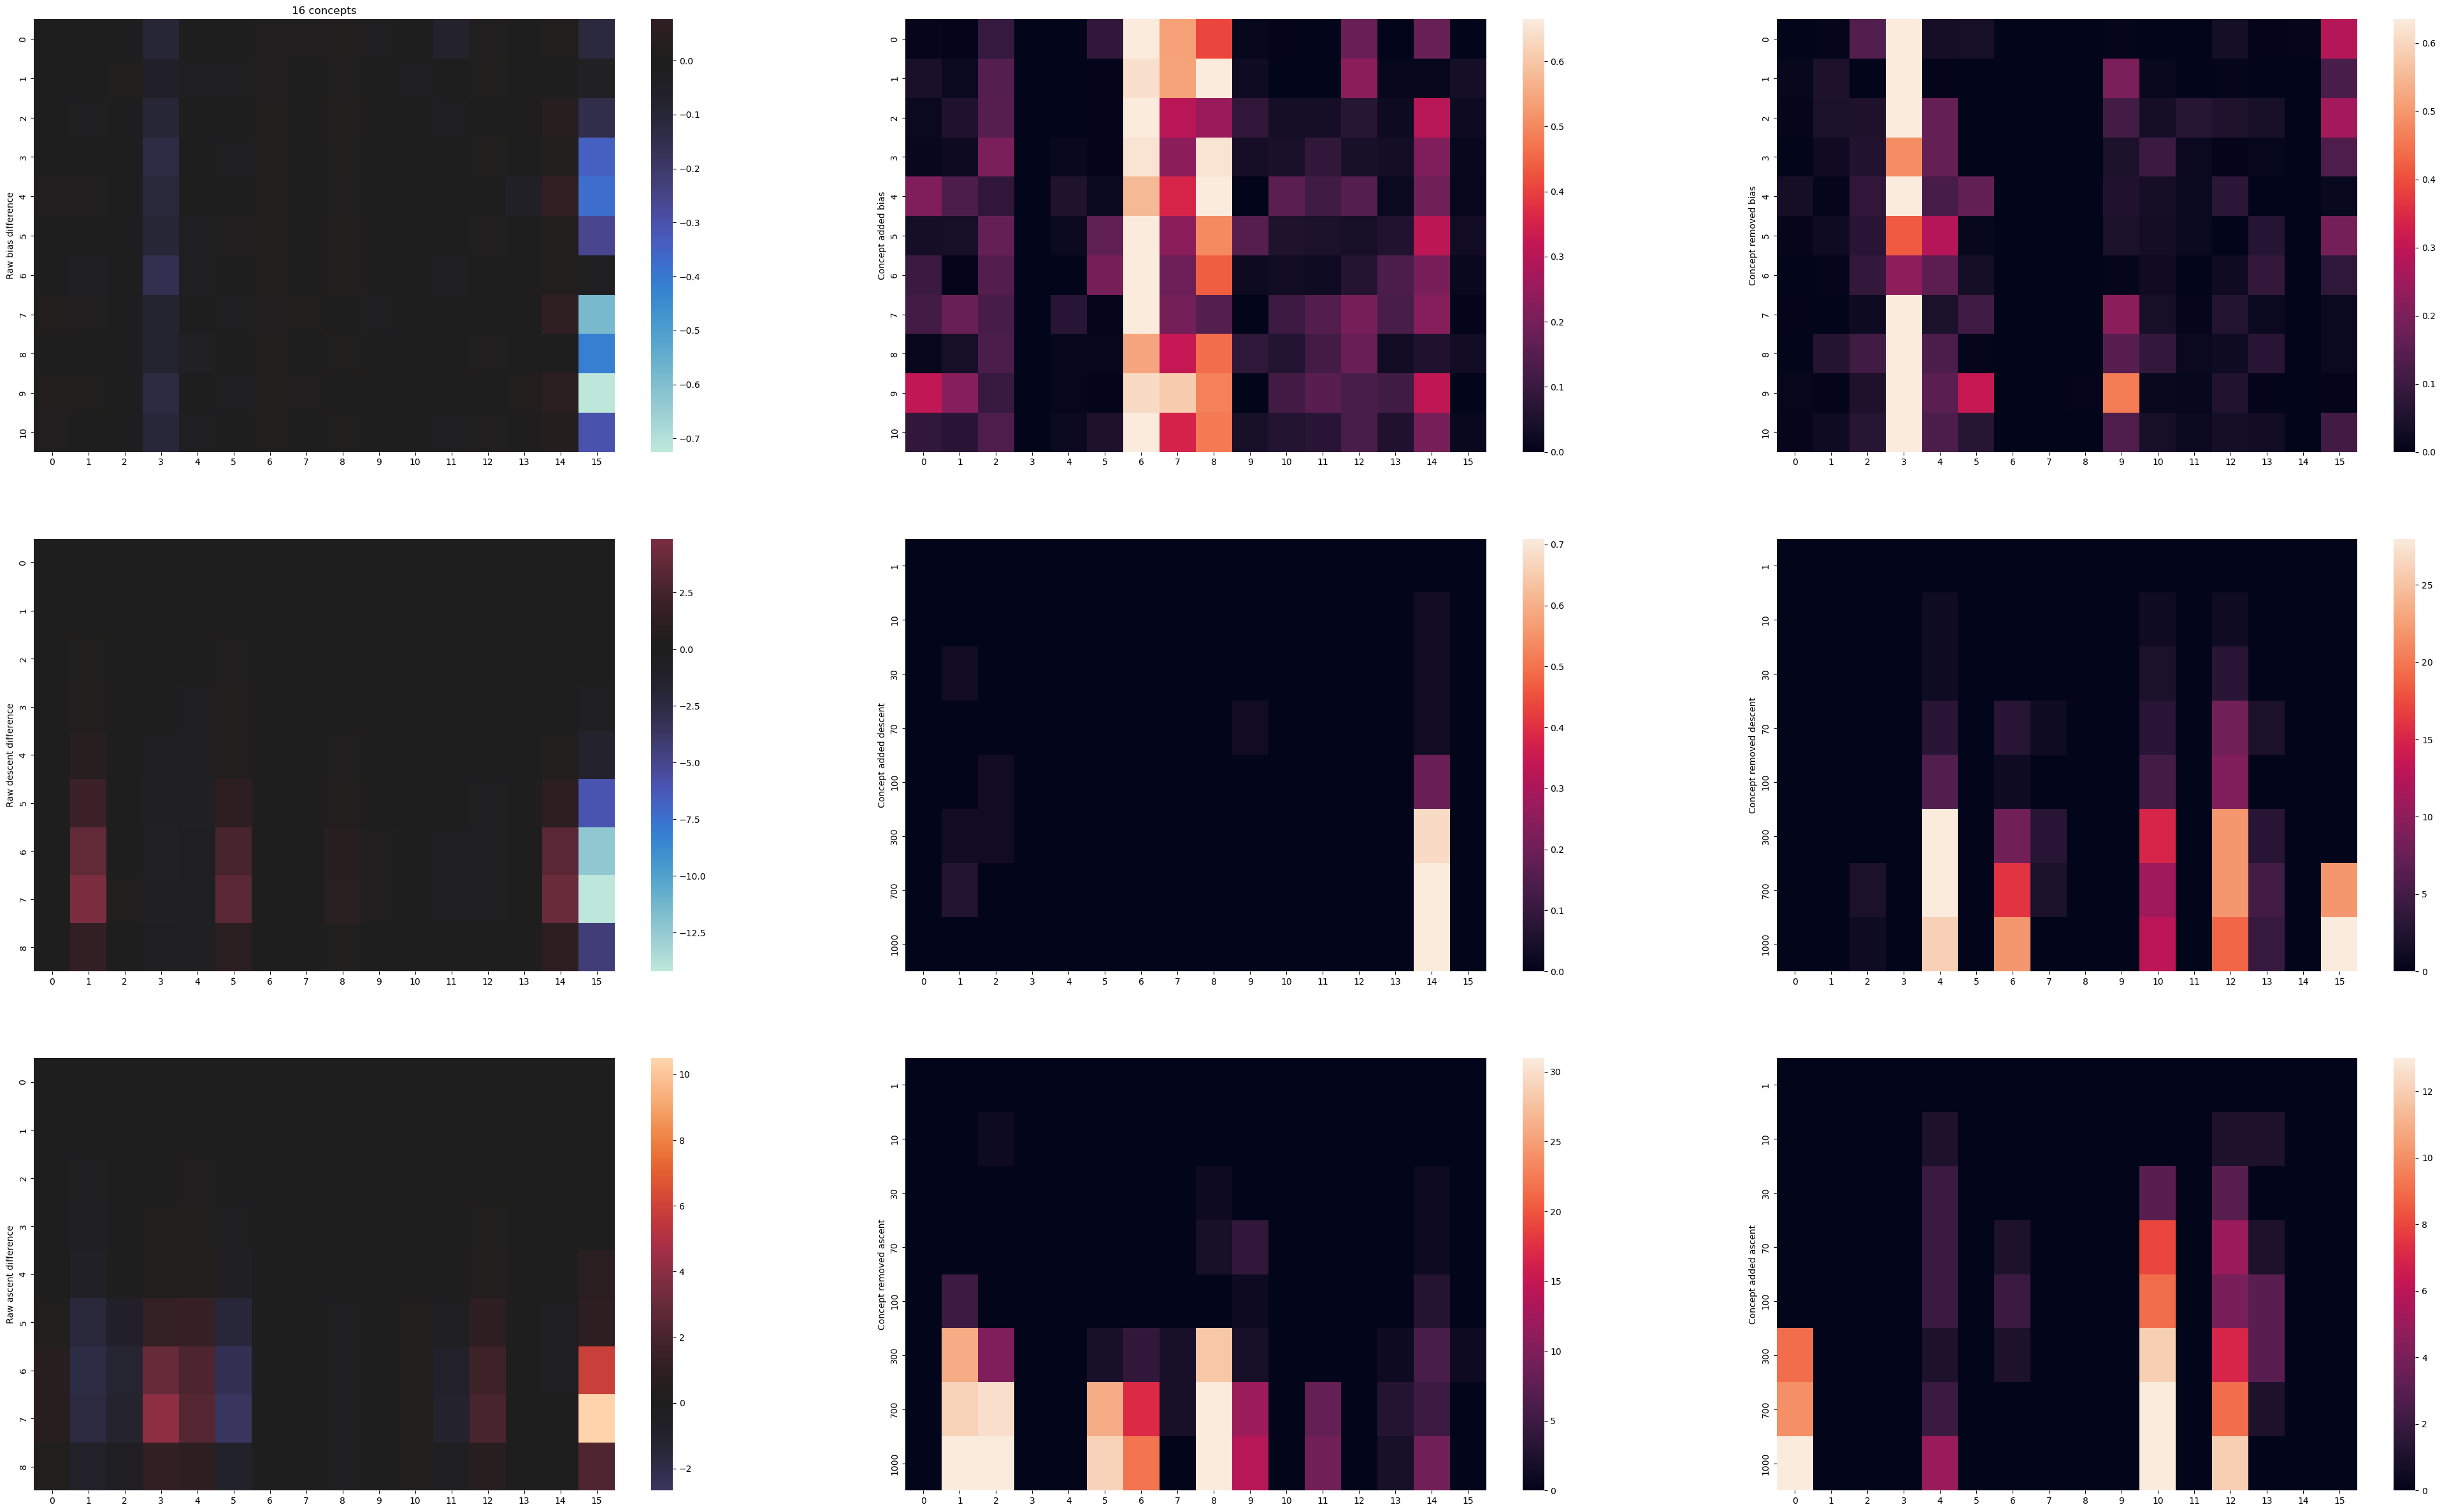

In [150]:
def show_expe(exp_id, studied_bias, concept_id, patch_id):
    concept_amounts = [4, 8, 16, 32]
    patch_sizes = [4, 8, 16, 28]
    amount_of_concept = concept_amounts[concept_id]
    patch_size = patch_sizes[patch_id]
    fig, axes = plt.subplots(3, 3, figsize=(50,30))
    with open(f"/data/4vitry/models/{exp_name}/bias_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    with open(f"/data/4vitry/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    table = []
    for i in range(10):
        table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
    table.append(sum(table)/len(table))

    table1 = []
    for i in range(10):
        table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0)/len(bias_res[studied_bias][i][0]))
    table1.append(sum(table1)/len(table1))

    table2 = []
    for i in range(10):
        table2.append(((bias_res[studied_bias][i][1] == 0) & (bias_res[studied_bias][i][0] > 0)).sum(axis=0)/len(bias_res[studied_bias][i][0]))
    table2.append(sum(table2)/len(table2))

    descent_added = []
    descent_removed = []
    ascent_added = []
    ascent_removed = []
    descent_raw_difference = []
    ascent_raw_difference = []
    for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
        table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
        descent_added.append(table_["descent_added_concept"]/table_["data_size"])
        descent_removed.append(table_["descent_removed_concept"])
        ascent_added.append(table_["ascent_added_concept"])
        ascent_removed.append(table_["ascent_removed_concept"])
        descent_raw_difference.append(table_["descent_raw_difference"])
        ascent_raw_difference.append(table_["ascent_raw_difference"])
    descent_raw_difference.append(sum(descent_raw_difference)/len(descent_raw_difference))
    ascent_raw_difference.append(sum(ascent_raw_difference)/len(ascent_raw_difference))

    sb.heatmap(table, center=0, annot=False, ax=axes[0][0])
    axes[0][0].set(ylabel="Raw bias difference", title=f"{amount_of_concept} concepts")
    sb.heatmap(table1, vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[0][1])
    axes[0][1].set(ylabel="Concept added bias")
    sb.heatmap(table2, vmin=0, vmax=table2[-1].max(), annot=False, ax=axes[0][2])
    axes[0][2].set(ylabel="Concept removed bias")

    sb.heatmap(descent_raw_difference, center=0, ax=axes[1][0])
    axes[1][0].set(ylabel="Raw descent difference")
    sb.heatmap(descent_removed, vmin=0, vmax=descent_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[1][2])
    axes[1][2].set(ylabel="Concept removed descent")
    sb.heatmap(descent_added, vmin=0, vmax=descent_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[1][1])
    axes[1][1].set(ylabel="Concept added descent")

    sb.heatmap(ascent_raw_difference, center=0, ax=axes[2][0])
    axes[2][0].set(ylabel="Raw ascent difference")
    sb.heatmap(ascent_added, vmin=0, vmax=ascent_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[2][2])
    axes[2][2].set(ylabel="Concept added ascent")
    sb.heatmap(ascent_removed, vmin=0, vmax=ascent_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[2][1])
    axes[2][1].set(ylabel="Concept removed ascent")

    v_bias_identified = np.array(descent_removed)
    v_bias_real = table1[-1]
    res = np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
    print(f"For {amount_of_concept} concept, the vector similarity is : {res}")

show_expe(exp_id=11, studied_bias=2, concept_id=2, patch_id=2)

Concept 0


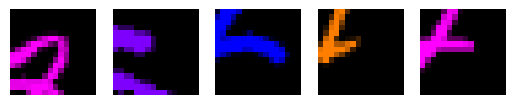




Concept 1


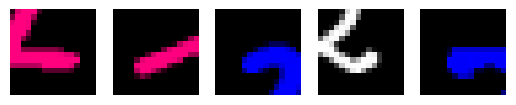




Concept 2


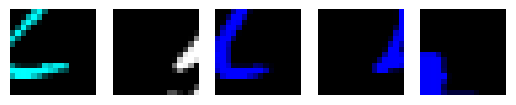




Concept 3


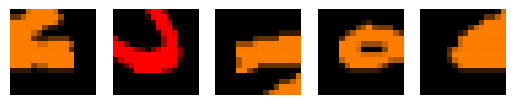




Concept 4


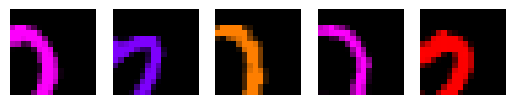




Concept 5


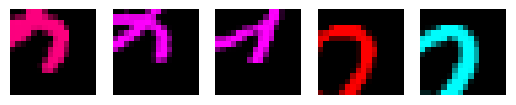




Concept 6


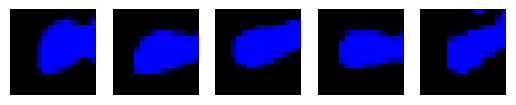




Concept 7


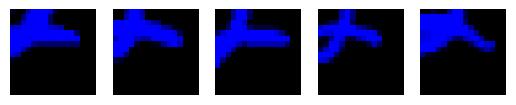




Concept 8


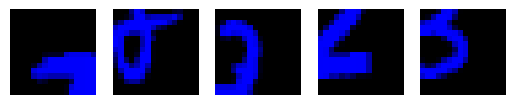




Concept 9


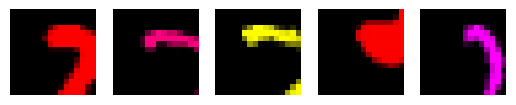




Concept 10


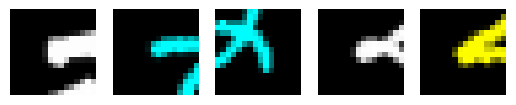




Concept 11


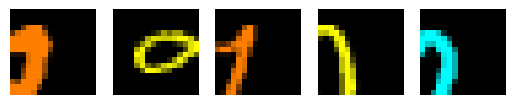




Concept 12


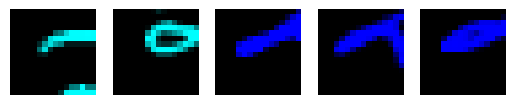




Concept 13


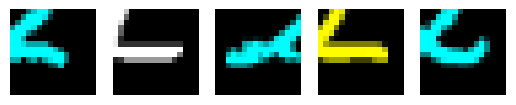




Concept 14


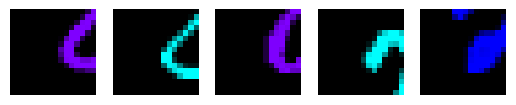




Concept 15


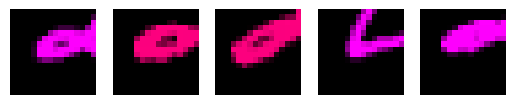

In [149]:
from math import ceil
studied_bias = 2
concept_id = 2
patch_size_id = 2
number_of_concepts = concept_amounts[concept_id]
def show(img, **kwargs):
  img = np.array(img)
  if img.shape[0] == 3:
    img = img.transpose(1, 2, 0)

  img -= img.min();img /= img.max()
  plt.imshow(img, **kwargs); plt.axis('off')

with open(f"/data/4vitry/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_size_id}.pkl", "rb") as f:
    concept_res = pkl.load(f)

crops_u = concept_res["concept_parameters"][studied_bias]["crops_u"]
crops = concept_res["concept_parameters"][studied_bias]["crops"]
nb_crops=5
for c_id in range(number_of_concepts):

  best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
  best_crops = crops[best_crops_ids]

  print("Concept", c_id)
  for i in range(nb_crops):
    plt.subplot(ceil(nb_crops/5), 5, i+1)
    show(best_crops[i])
  plt.show()
  print('\n\n')

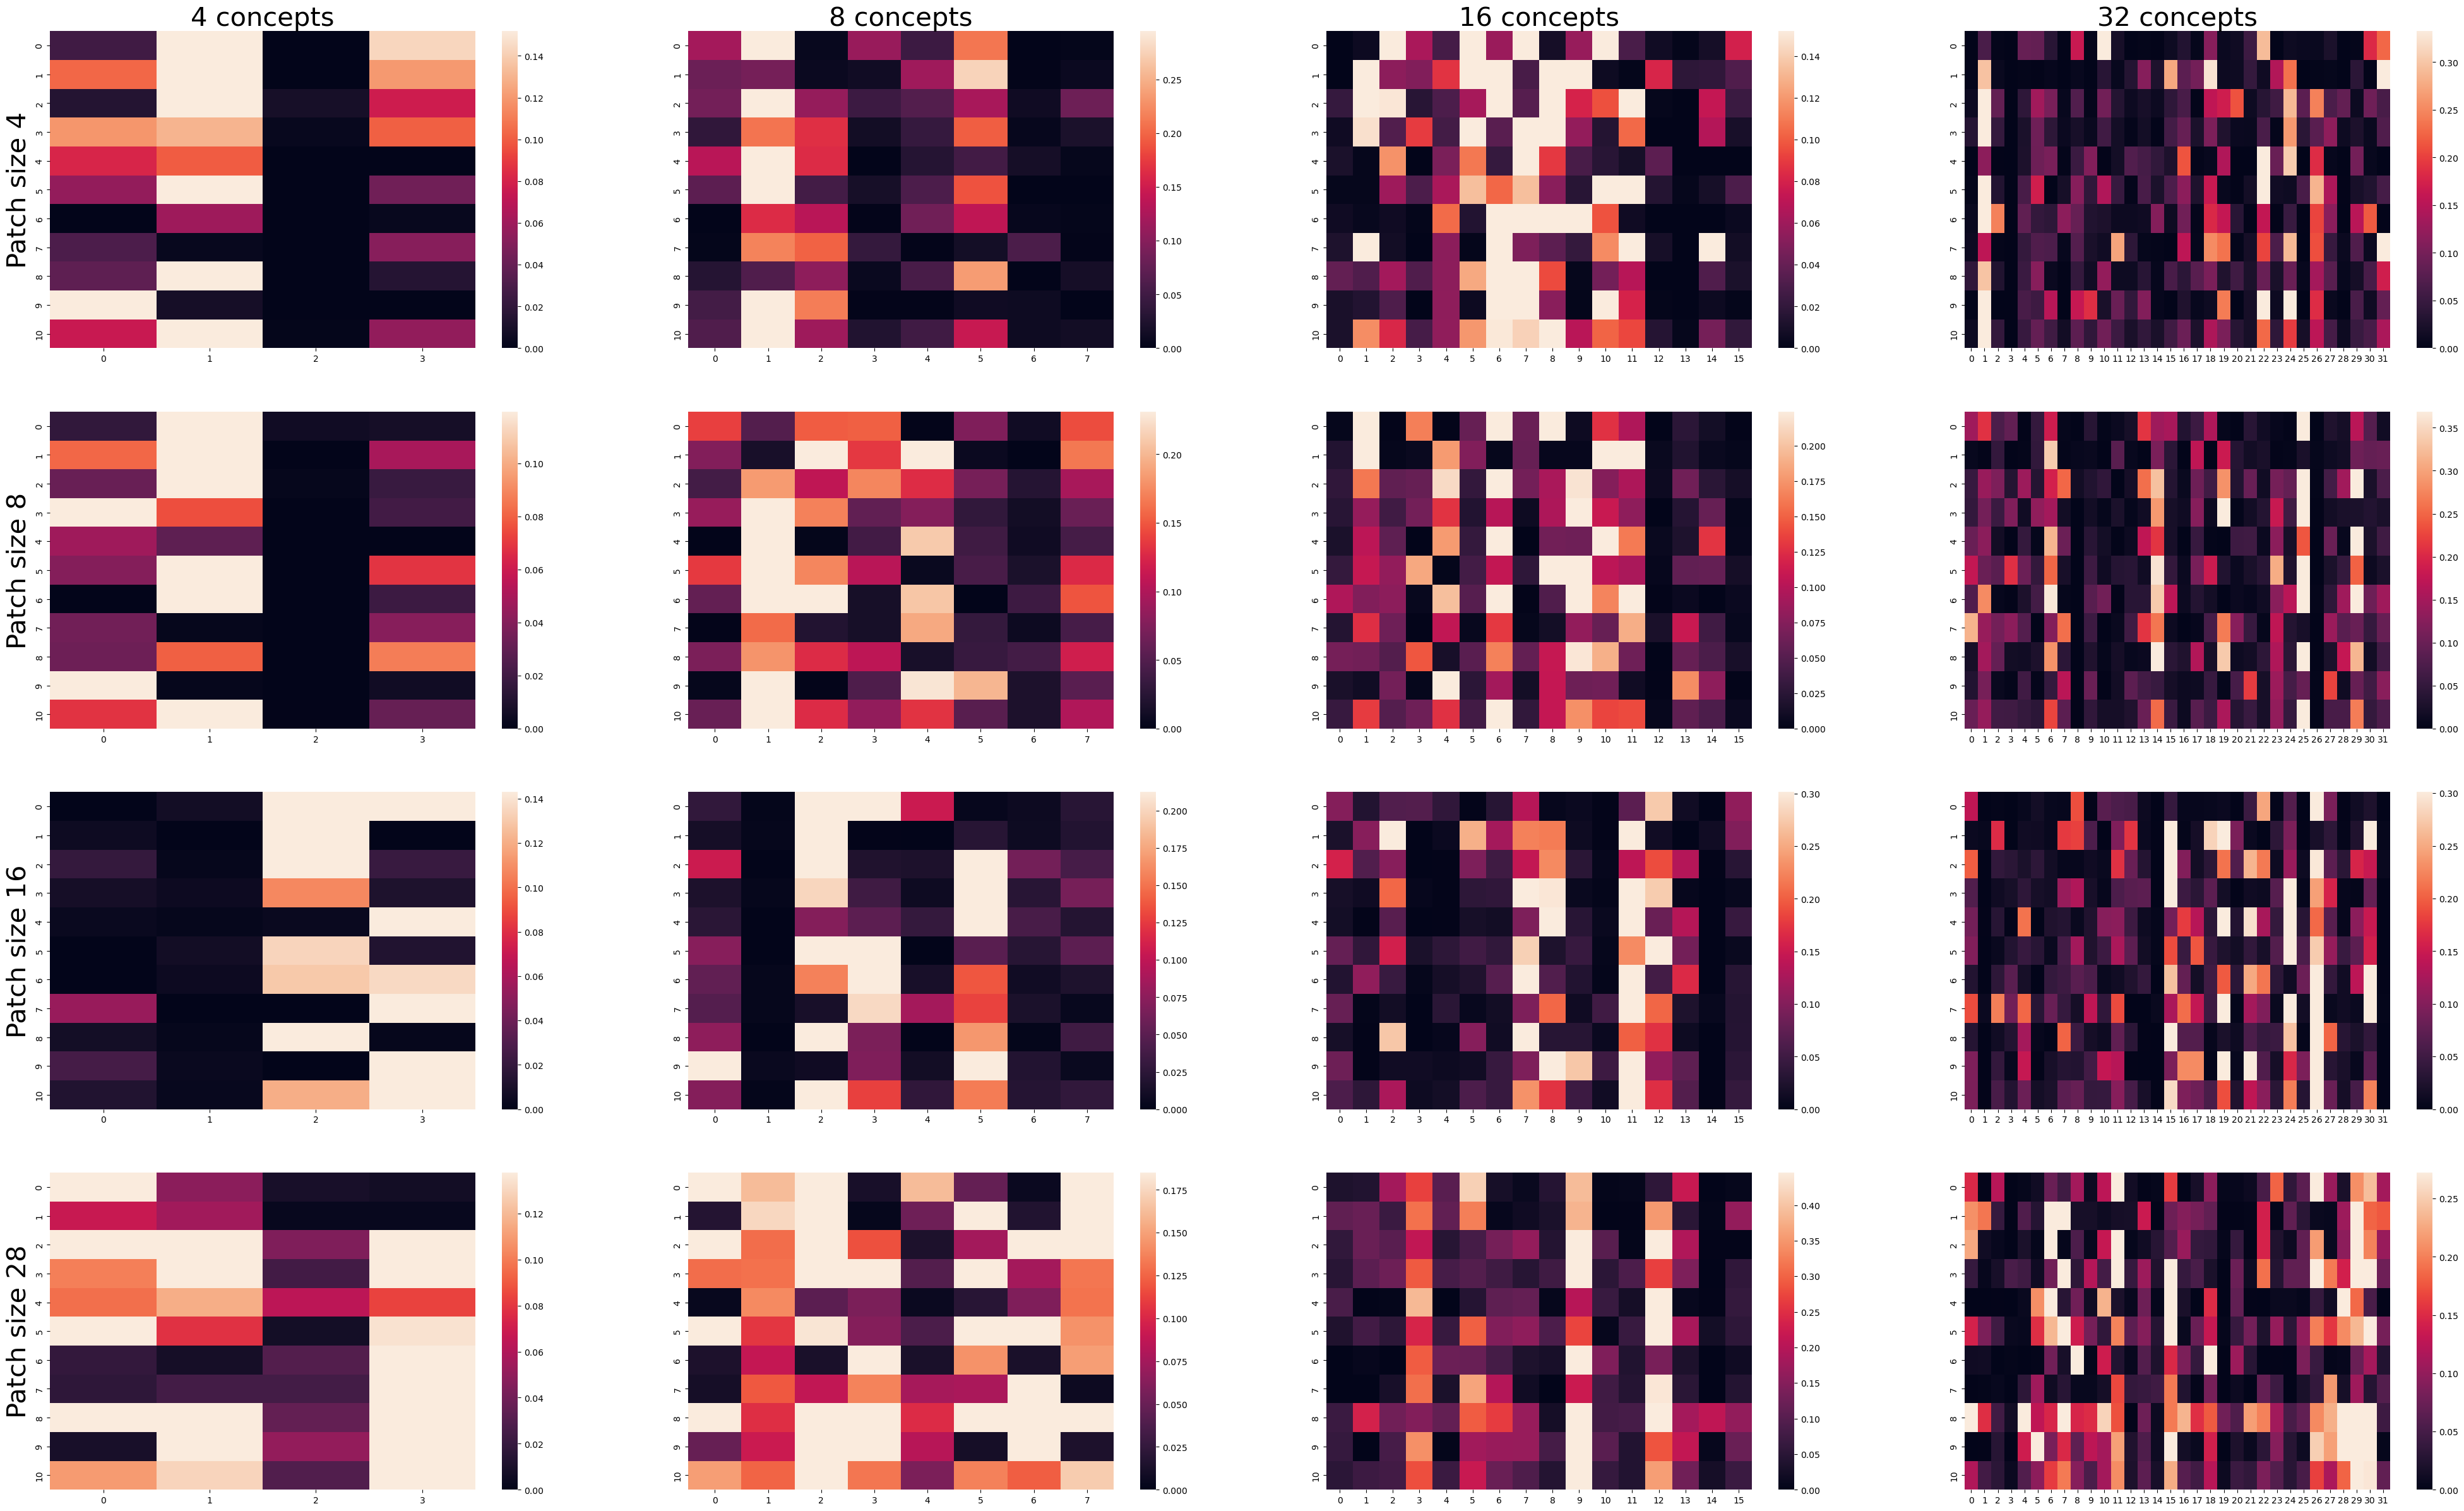

In [132]:
exp_id = 13
studied_bias = 8
concept_range = range(0,4)
concept_amounts = [4, 8, 16, 32]
patch_size_range = range(0,4)
patch_sizes = [4, 8, 16, 28]
fig, axes = plt.subplots(len(patch_size_range), len(concept_range), figsize=(50,30))
for index, concept_id in enumerate(concept_range):
    for indexj, patch_id in enumerate(patch_size_range):
        patch_size = patch_sizes[patch_id]
        amount_of_concept = concept_amounts[concept_id]
        with open(f"/data/4vitry/models/{exp_name}/bias_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
            bias_res = pkl.load(f)
        # with open(f"/data/4vitry/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        #     concept_res = pkl.load(f)
        table = []
        for i in range(10):
            table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
        table.append(sum(table)/len(table))

        table1 = []
        for i in range(10):
            table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0)/len(bias_res[studied_bias][i][0]))
        table1.append(sum(table1)/len(table1))

        table2 = []
        for i in range(10):
            table2.append(((bias_res[studied_bias][i][1] == 0) & (bias_res[studied_bias][i][0] > 0)).sum(axis=0)/len(bias_res[studied_bias][i][0]))
        table2.append(sum(table2)/len(table2))
        # sb.heatmap(table, center=0, annot=False, ax=axes[indexj][index])
        # axes[indexj][index].set(ylabel="Raw bias difference", title=f"{amount_of_concept} concepts")
        sb.heatmap(table1, vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[indexj][index], cbar=True)
        # axes[indexj][index].set(ylabel="Class label", xlabel="Concept id")
        if index == 0:
            axes[indexj][index].set_ylabel(f"Patch size {patch_size}", fontsize=30)
        if indexj == 0:
            axes[indexj][index].set_title(f"{amount_of_concept} concepts", {"fontsize":30})
        # sb.heatmap(table2, vmin=0, vmax=table2[-1].max(), annot=False, ax=axes[indexj][index])
        # axes[indexj][index].set(ylabel="Concept removed bias")

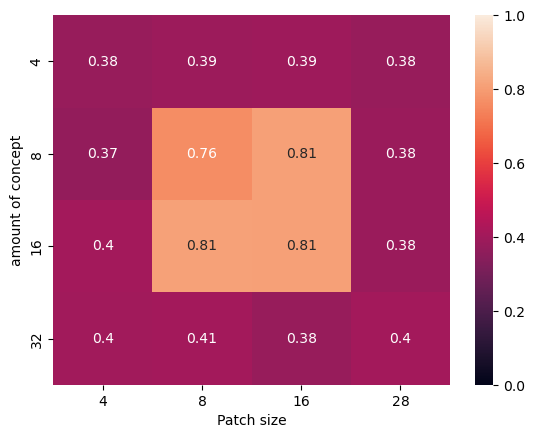

In [108]:
def singleBiasError(table):
    # Implements a normalized cross entropy loss function between the softmax of the table and the max arg of the mean of said table
    loss_fn = nn.CrossEntropyLoss()
    arg_bias = torch.argmax(torch.Tensor(sum(table)/len(table)))
    res = 0
    for line in table:
        values = torch.Tensor(sc.softmax(100*line))
        res += loss_fn(values, arg_bias)/np.log(len(line))
    return res/len(table)

concept_range = range(0,4)
concept_amounts = [4, 8, 16, 32]
patch_size_range = range(0,4)
patch_sizes = [4, 8, 16, 28]


error = []
bias_arg = []
error_fun = singleBiasError
for exp_id in range(3, 16):
    error.append([])
    bias_arg.append([])
    for studied_bias in range(10):
        error[-1].append([])
        bias_arg[-1].append([])
        for index, concept_id in enumerate(concept_range):
            error[-1][-1].append([])
            bias_arg[-1][-1].append([])
            for indexj, patch_id in enumerate(patch_size_range):
                patch_size = patch_sizes[patch_id]
                amount_of_concept = concept_amounts[concept_id]
                try :
                    with open(f"/data/4vitry/models/{exp_name}/bias_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
                        bias_res = pkl.load(f)
                    table1 = []
                    for i in range(10):
                        table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0)/len(bias_res[studied_bias][i][0]))
                    error[-1][-1][-1].append(error_fun(table1))
                    bias_arg[-1][-1][-1].append(torch.argmax(torch.Tensor(sum(table1)/len(table1))))
                except:
                    error[-1][-1][-1].append(0)
                    bias_arg[-1][-1][-1].append(0)
error= np.array(error)
s_error = error.mean(axis=0).mean(axis=0)
ax = sb.heatmap(s_error, vmin=0, vmax=1, annot=True, xticklabels=patch_sizes, yticklabels=concept_amounts)
ax.set(xlabel="Patch size", ylabel="amount of concept")
plt.show()

In [109]:
concept_amounts = [4, 8, 16, 32]
patch_sizes = [4, 8, 16, 28]
concept_id, patch_id = 1, 1

all_data = {"h0_distrib":None, "h1_distrib":None}
patch_size = patch_sizes[patch_id]
amount_of_concept = concept_amounts[concept_id]
for exp_id in range(3, 16):
    with open(f"/data/4vitry/models/{exp_name}/bias_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    for bias_label in range(10):
        bias_concept = int(bias_arg[exp_id-3][bias_label][concept_id][patch_id])
        not_bias_concept = list(range(concept_amounts[concept_id]))
        not_bias_concept.pop(bias_concept)
        for real_label, (concepts_without_bias, concepts_with_bias) in bias_res[bias_label].items():
            for exp_type, data in [("h0_distrib", concepts_without_bias), ("h1_distrib", concepts_with_bias)]:
                not_bias_data = np.concatenate(data.T[not_bias_concept])
                bias_data = data.T[bias_concept]
                assert(len(not_bias_data) == (concept_amounts[concept_id]-1) * len(bias_data))
                if all_data[exp_type] == None:
                    all_data[exp_type] = {"bias_concept":bias_data, "non_bias_concept":not_bias_data}
                else:
                    all_data[exp_type]["bias_concept"] = np.concatenate([all_data[exp_type]["bias_concept"], bias_data])
                    all_data[exp_type]["non_bias_concept"] = np.concatenate([all_data[exp_type]["non_bias_concept"],not_bias_data])


((np.float32(0.13230717), np.float32(0.00055022934)), (np.float32(0.06663446), np.float32(0.0002412776)))
((np.float32(0.12567326), np.float32(0.00042514325)), (np.float32(0.12854004), np.float32(0.0004030513)))


[Text(0.5, 1.0, 'Concept activation values for biased inputs'),
 Text(0.5, 0, 'Mean activation value for 100 samples')]

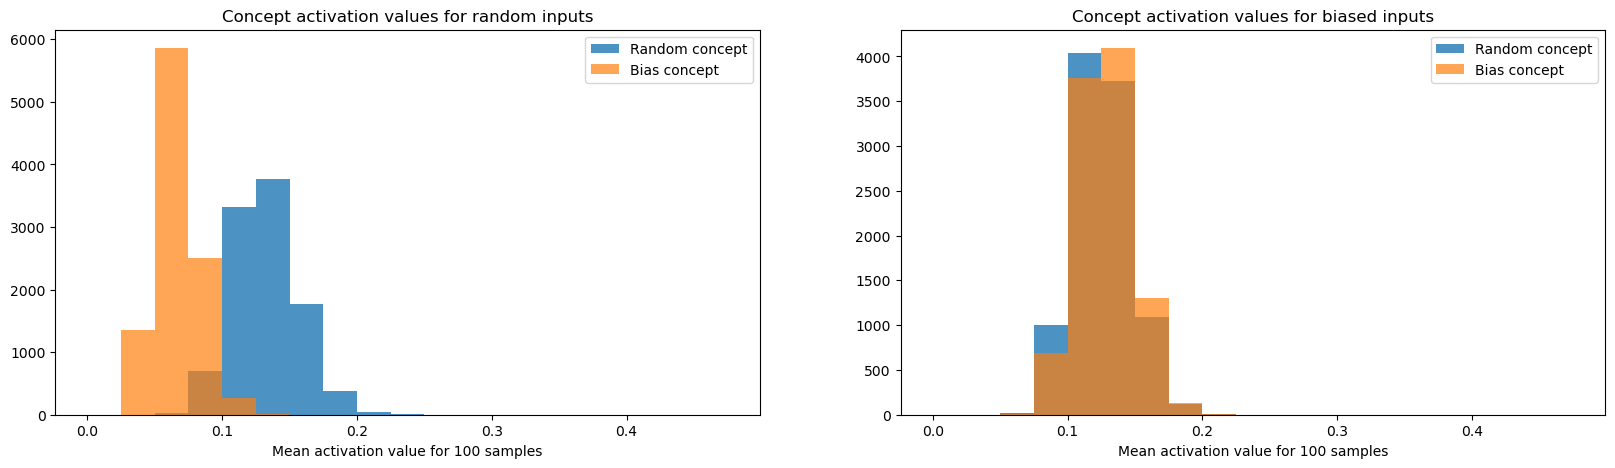

In [110]:
def draw_bootstrap_hist(data, sample_size, sample_amount, ax=None):
    full_data = np.concatenate(list(data.values()))
    bias_data = data["bias_concept"]
    res_gen, res_bias = np.array([np.random.choice(full_data, sample_size).mean() for _ in range(sample_amount)]), np.array([np.random.choice(bias_data, sample_size).mean() for _ in range(sample_amount)])
    # fig, axes = plt.subplots(2, figsize=(50,30))

    if ax:
        ax.hist(res_gen, bins=np.arange(0, 0.5, 0.025), label="Random concept", histtype="barstacked", alpha=.8)
        ax.hist(res_bias, bins=np.arange(0, 0.5, 0.025), label="Bias concept", histtype="barstacked", alpha=.7)
        ax.legend()
    else:
        plt.hist(res_gen, bins=np.arange(0, 0.5, 0.025), label="Random concept", histtype="barstacked", alpha=.8)
        plt.hist(res_bias, bins=np.arange(0, 0.5, 0.025), label="Bias concept", histtype="barstacked", alpha=.7)
        plt.legend()
        plt.show()
    return (res_gen.mean(), res_gen.var()), (res_bias.mean(), res_bias.var())

sample_size = 100
sample_amount = 10000
fig, axes = plt.subplots(1, 2, figsize=(20,5))
print(draw_bootstrap_hist(all_data["h0_distrib"], sample_size, sample_amount, ax=axes[0]))
print(draw_bootstrap_hist(all_data["h1_distrib"], sample_size, sample_amount, ax=axes[1]))
axes[0].set(title="Concept activation values for random inputs", xlabel=f"Mean activation value for {sample_size} samples")
axes[1].set(title="Concept activation values for biased inputs", xlabel=f"Mean activation value for {sample_size} samples")

In [111]:
concept_amounts = [4, 8, 16, 32]
patch_sizes = [4, 8, 16, 28]
concept_id, patch_id = 2, 2

all_data = {"h0_distrib":None, "h1_distrib":None}
patch_size = patch_sizes[patch_id]
amount_of_concept = concept_amounts[concept_id]
for exp_id in range(3, 16):
    with open(f"/data/4vitry/models/{exp_name}/bias_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    for bias_label in range(10):
        bias_concept = int(bias_arg[exp_id-3][bias_label][concept_id][patch_id])
        not_bias_concept = list(range(concept_amounts[concept_id]))
        not_bias_concept.pop(bias_concept)
        for real_label, (concepts_without_bias, concepts_with_bias) in bias_res[bias_label].items():
            for exp_type, data in [("h0_distrib", concepts_without_bias), ("h1_distrib", concepts_with_bias)]:
                not_bias_data = np.concatenate(data.T[not_bias_concept])
                bias_data = data.T[bias_concept]
                assert(len(not_bias_data) == (concept_amounts[concept_id]-1) * len(bias_data))
                if all_data[exp_type] == None:
                    all_data[exp_type] = {"bias_concept":bias_data, "non_bias_concept":not_bias_data}
                else:
                    all_data[exp_type]["bias_concept"] = np.concatenate([all_data[exp_type]["bias_concept"], bias_data])
                    all_data[exp_type]["non_bias_concept"] = np.concatenate([all_data[exp_type]["non_bias_concept"],not_bias_data])

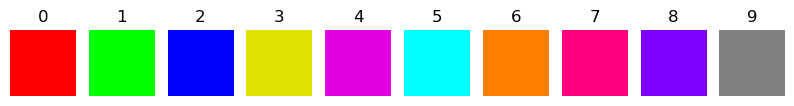

In [112]:
COLOUR_MAP = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [225, 225, 0], [225, 0, 225],
                  [0, 255, 255], [255, 128, 0], [255, 0, 128], [128, 0, 255], [128, 128, 128]]
fig, axes = plt.subplots(1,10, figsize=(10,10))
for label, color in enumerate(COLOUR_MAP):
    axes[label].set_axis_off()
    axes[label].set_title(loc="center", label=f"{label}")
    axes[label].imshow([[color]])

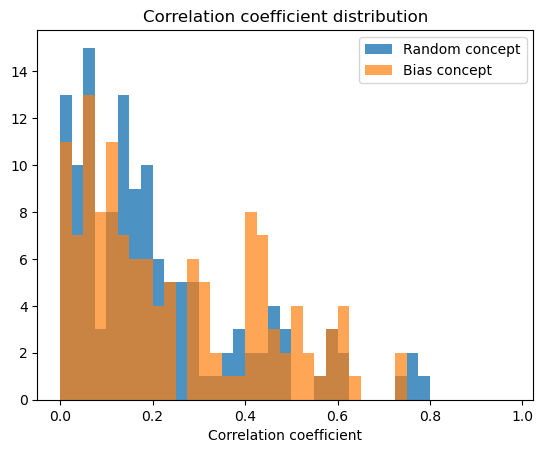

0.2088680054320672 0.18396465040936902
0.24315215298194784 0.1915853696877373


In [113]:
concept_amounts = [4, 8, 16, 32]
patch_sizes = [4, 8, 16, 28]
concept_id, patch_id = 1, 1

def bias_similarity(a, b):
    return cos_sim(np.array(COLOUR_MAP[a]).reshape(1, -1), np.array(COLOUR_MAP[b]).reshape(1, -1))

res = [np.array([]), np.array([])]
for exp_id in range(3, 16):
    with open(f"/data/4vitry/models/{exp_name}/correlation_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    for decomposer_label in bias_res:
        res_table = None
        is_init = False
        bias_concept = int(bias_arg[exp_id-10][decomposer_label][concept_id][patch_id])
        not_bias_concept = list(range(concept_amounts[concept_id]))
        for bias_label in bias_res[decomposer_label]:
            value = bias_similarity(decomposer_label, bias_label)
            table = np.concatenate([bias_res[decomposer_label][bias_label].T, value * np.ones((1,len(bias_res[decomposer_label][bias_label])))], axis = 0)
            if not is_init:
                res_table = table
                is_init = True
            else:
                res_table = np.concatenate([res_table, table], axis = 1)
        cor = np.corrcoef(res_table)[-1][:-1]
        res[0] = np.concatenate([res[0], np.absolute(cor[not_bias_concept])])
        res[1] = np.concatenate([res[1], np.absolute(cor[bias_concept:bias_concept+1])])
fig, ax = plt.subplots()
baseline = np.random.choice(res[0], len(res[1]))
ax.hist(baseline, bins=np.arange(0, 1, 0.025), label="Random concept", histtype="barstacked", alpha=.8)
ax.hist(res[1], bins=np.arange(0, 1, 0.025), label="Bias concept", histtype="barstacked", alpha=.7)
ax.set(xlabel="Correlation coefficient", title="Correlation coefficient distribution")
plt.legend()
plt.show()
print(baseline.mean(), baseline.std())
print(res[1].mean(), res[1].std())

For 10 concept, the vector similarity is : [0.         0.00068611 0.00128423 0.00205832 0.00188236 0.08538765
 0.1588406  0.16180989]
For 30 concept, the vector similarity is : [0.         0.00304708 0.01262576 0.02997499 0.04895127 0.11227038
 0.17581403 0.16183911]
For 70 concept, the vector similarity is : [1.04010821e-04 2.20419214e-03 1.16988162e-02 3.66921932e-02
 4.90000067e-02 1.27172720e-01 1.70787210e-01 1.78322312e-01]


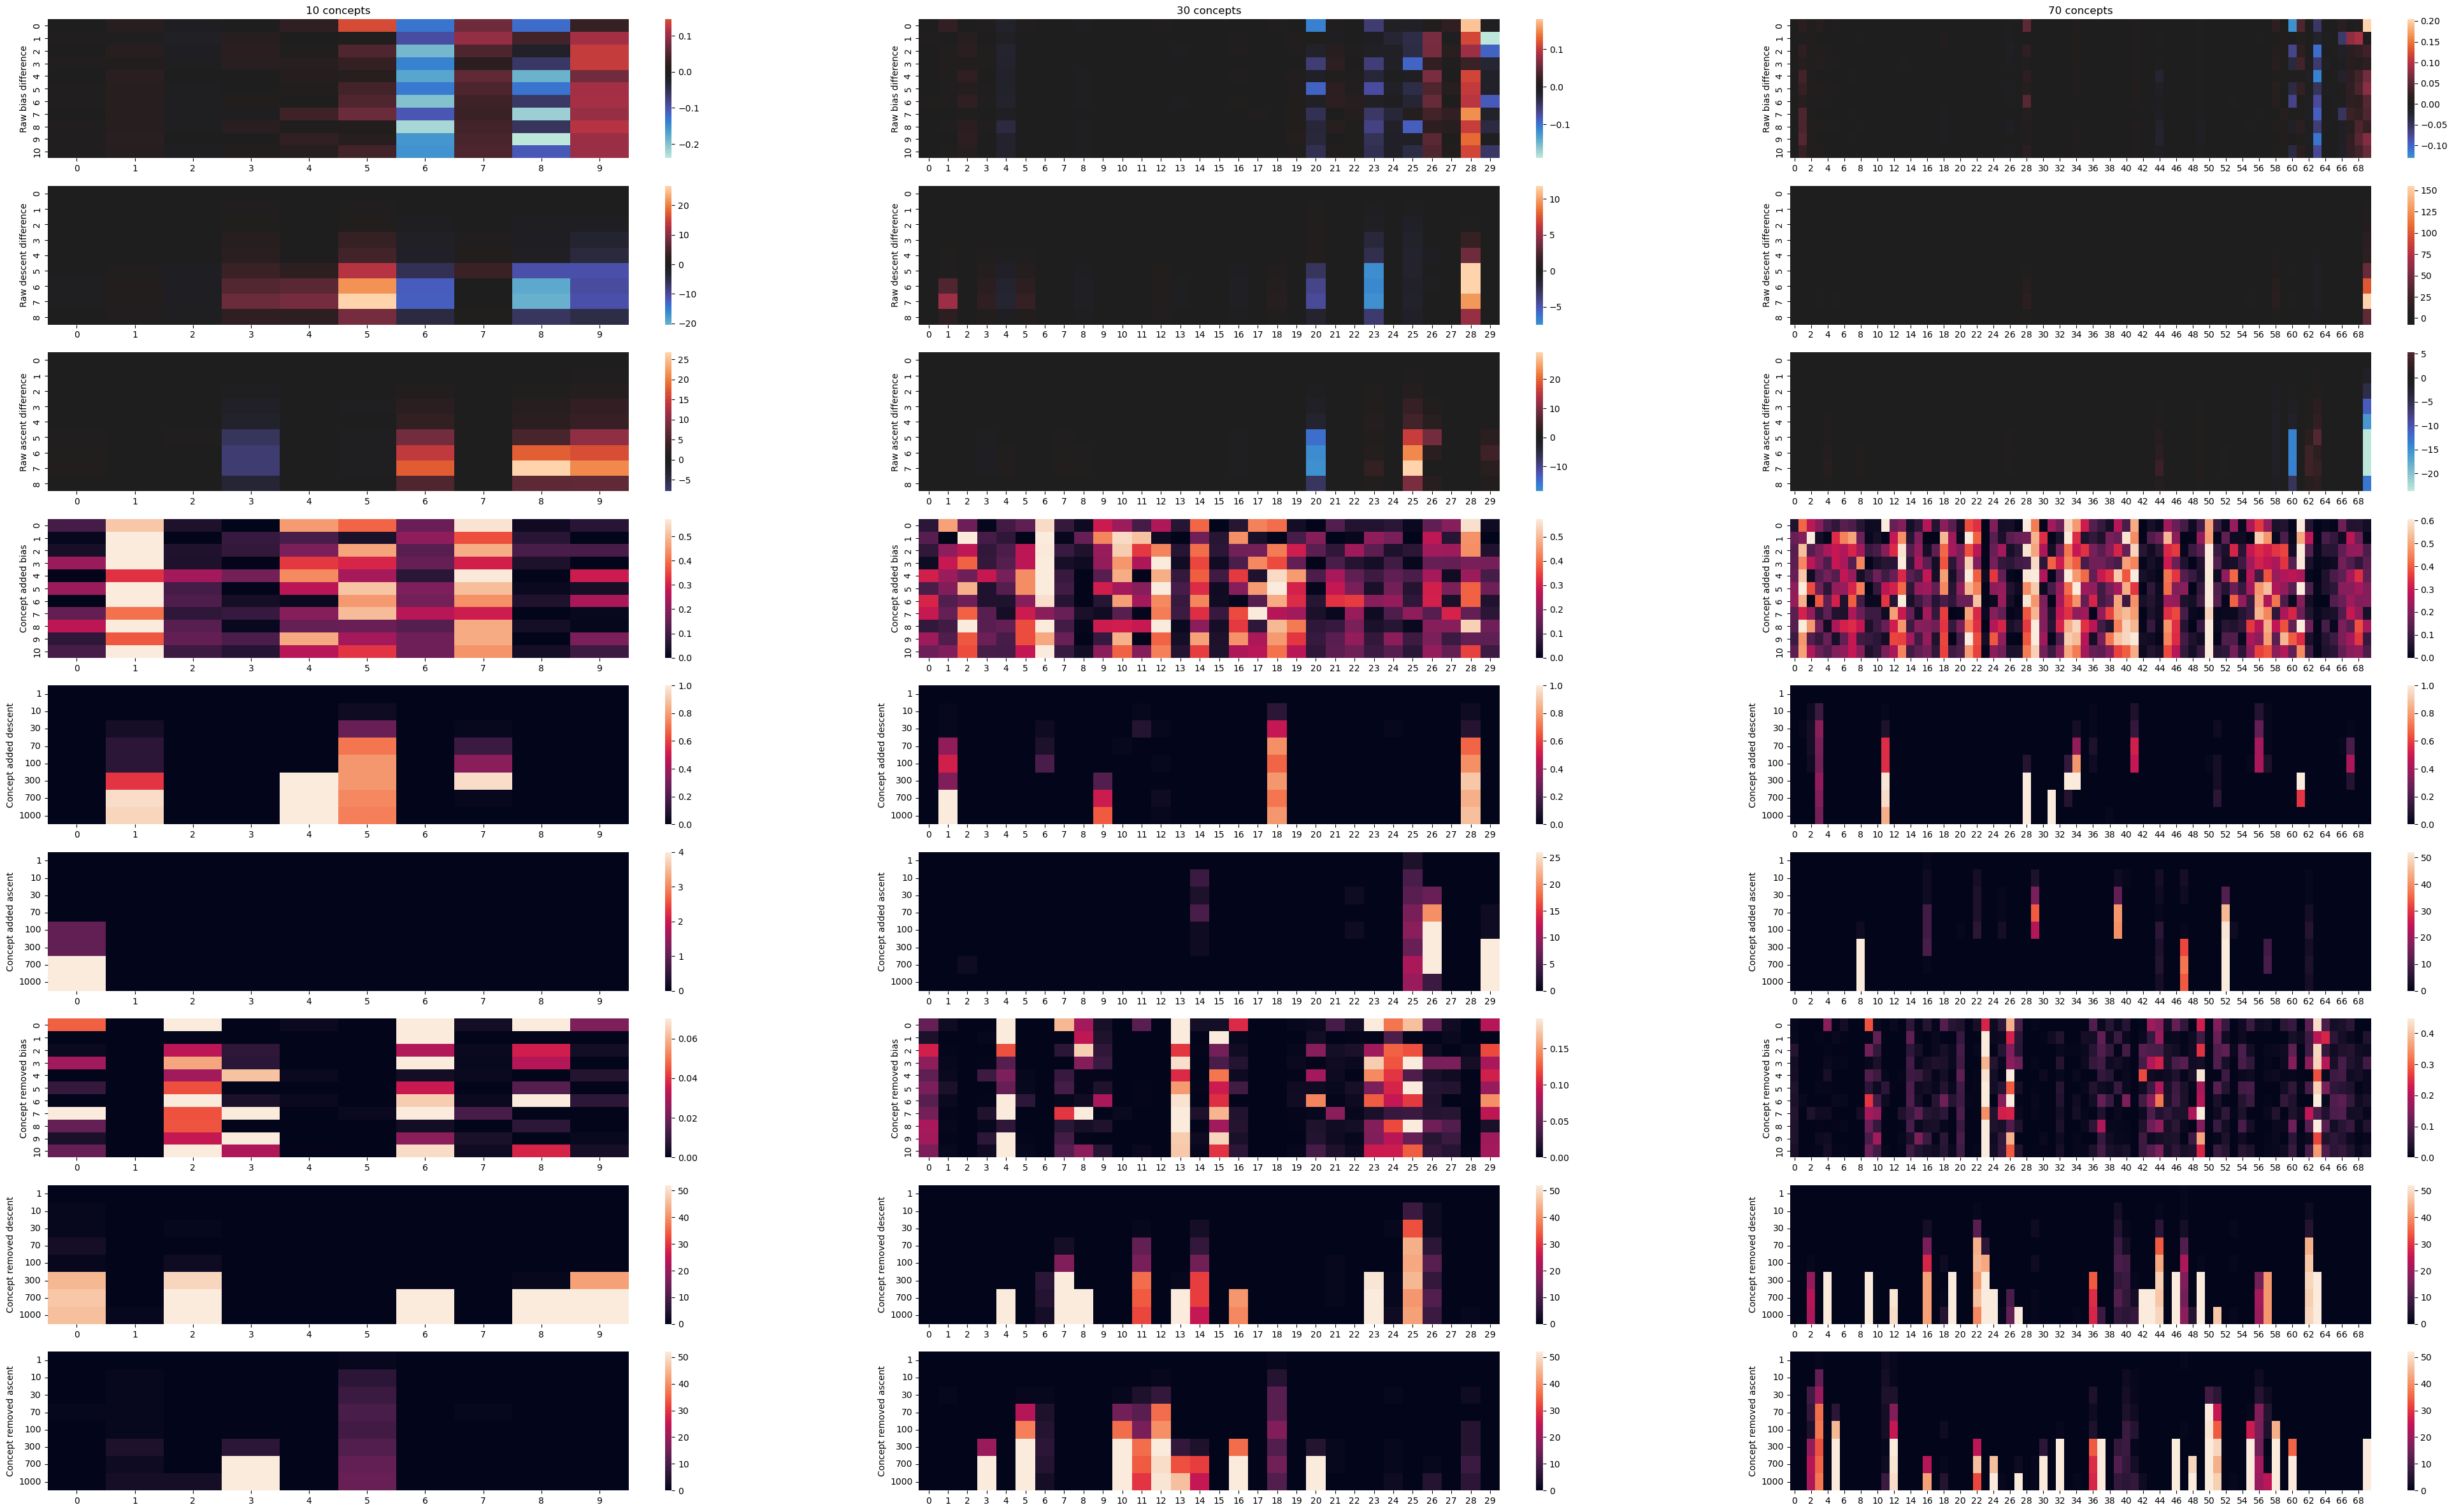

In [28]:
exp_id = 1
studied_bias = 0
concept_range = range(0,3)
concept_amounts = [10, 30, 70, 100]
fig, axes = plt.subplots(9, len(concept_range), figsize=(50,30))
for index, concept_id in enumerate(concept_range):
    amount_of_concept = concept_amounts[concept_id]
    with open(f"/data/4vitry/models/{exp_name}/bias_{exp_id}_{concept_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    with open(f"/data/4vitry/models/{exp_name}/concepts_{exp_id}_{concept_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    table = []
    for i in range(10):
        table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
    table.append(sum(table)/len(table))

    table1 = []
    for i in range(10):
        table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0)/len(bias_res[studied_bias][i][0]))
    table1.append(sum(table1)/len(table1))

    table2 = []
    for i in range(10):
        table2.append(((bias_res[studied_bias][i][1] == 0) & (bias_res[studied_bias][i][0] > 0)).sum(axis=0)/len(bias_res[studied_bias][i][0]))
    table2.append(sum(table2)/len(table2))

    descent_added = []
    descent_removed = []
    ascent_added = []
    ascent_removed = []
    descent_raw_difference = []
    ascent_raw_difference = []
    for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
        table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
        descent_added.append(table_["descent_added_concept"]/table_["data_size"])
        descent_removed.append(table_["descent_removed_concept"])
        ascent_added.append(table_["ascent_added_concept"])
        ascent_removed.append(table_["ascent_removed_concept"])
        descent_raw_difference.append(table_["descent_raw_difference"])
        ascent_raw_difference.append(table_["ascent_raw_difference"])
    descent_raw_difference.append(sum(descent_raw_difference)/len(descent_raw_difference))
    ascent_raw_difference.append(sum(ascent_raw_difference)/len(ascent_raw_difference))

    sb.heatmap(table, center=0, annot=False, ax=axes[0][index])
    axes[0][index].set(ylabel="Raw bias difference", title=f"{amount_of_concept} concepts")
    sb.heatmap(descent_raw_difference, center=0, ax=axes[1][index])
    axes[1][index].set(ylabel="Raw descent difference")
    sb.heatmap(ascent_raw_difference, center=0, ax=axes[2][index])
    axes[2][index].set(ylabel="Raw ascent difference")
    sb.heatmap(table1, vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[3][index])
    axes[3][index].set(ylabel="Concept added bias")
    sb.heatmap(table2, vmin=0, vmax=table2[-1].max(), annot=False, ax=axes[6][index])
    axes[6][index].set(ylabel="Concept removed bias")
    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(descent_added, vmin=0, vmax=descent_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[4][index])
    axes[4][index].set(ylabel="Concept added descent")

    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(descent_removed, vmin=0, vmax=descent_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[7][index])
    axes[7][index].set(ylabel="Concept removed descent")
    sb.heatmap(ascent_added, vmin=0, vmax=ascent_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[5][index])
    axes[5][index].set(ylabel="Concept added ascent")
    sb.heatmap(ascent_removed, vmin=0, vmax=ascent_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[8][index])
    axes[8][index].set(ylabel="Concept removed ascent")

    v_bias_identified = np.array(descent_removed)
    v_bias_real = table1[-1]
    res = np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
    print(f"For {amount_of_concept} concept, the vector similarity is : {res}")

Concept 0


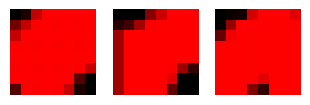




Concept 1


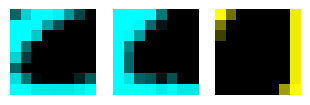




Concept 2


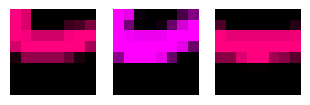




Concept 3


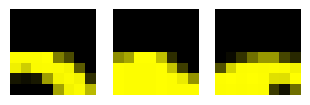




Concept 4


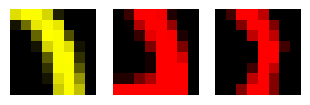




Concept 5


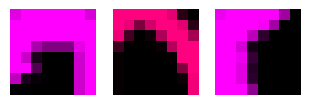




Concept 6


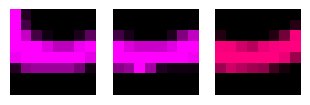




Concept 7


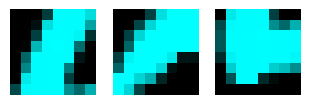

IndexError: index 8 is out of bounds for axis 1 with size 8

In [79]:
from math import ceil
def show(img, **kwargs):
  img = np.array(img)
  if img.shape[0] == 3:
    img = img.transpose(1, 2, 0)

  img -= img.min();img /= img.max()
  plt.imshow(img, **kwargs); plt.axis('off')

with open(f"/data/4vitry/models/{exp_name}/concepts_{exp_id}_1_1.pkl", "rb") as f:
    concept_res = pkl.load(f)

studied_bias=0
crops_u = concept_res["concept_parameters"][studied_bias]["crops_u"]
crops = concept_res["concept_parameters"][studied_bias]["crops"]
number_of_concepts=10
nb_crops=3
for c_id in range(number_of_concepts):

  best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
  best_crops = crops[best_crops_ids]

  print("Concept", c_id)
  for i in range(nb_crops):
    plt.subplot(ceil(nb_crops/5), 5, i+1)
    show(best_crops[i])
  plt.show()
  print('\n\n')

In [80]:
def normalize(a):
    b = (a - a.min())/(a.max() - a.min())
    return b/b.sum()

normalize(np.array(truc)) @ normalize(table1[-1]).T

array([6.19386430e-06, 5.43403792e-05, 1.21191960e-04, 2.01876017e-04,
       2.37653963e-04, 2.93349480e-04, 2.93510001e-04, 2.85641925e-04])

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.         0.02026047 0.02026047 0.03522427 0.07134578 0.11322706
 0.12315469 0.11519522]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.         0.         0.00229985 0.01781439 0.05393329 0.11537879
 0.13220349 0.13486151]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


...

For 10 concept, the vector similarity is : [0.         0.         0.02984095 0.07657822 0.07281117 0.09801717
 0.10612371 0.17904567]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.         0.01441814 0.05293094 0.1151583  0.14814995 0.17802346
 0.19936721 0.20678888]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.00624652 0.01314273 0.06828828 0.15215918 0.20316123 0.2881438
 0.3146795  0.3143715 ]


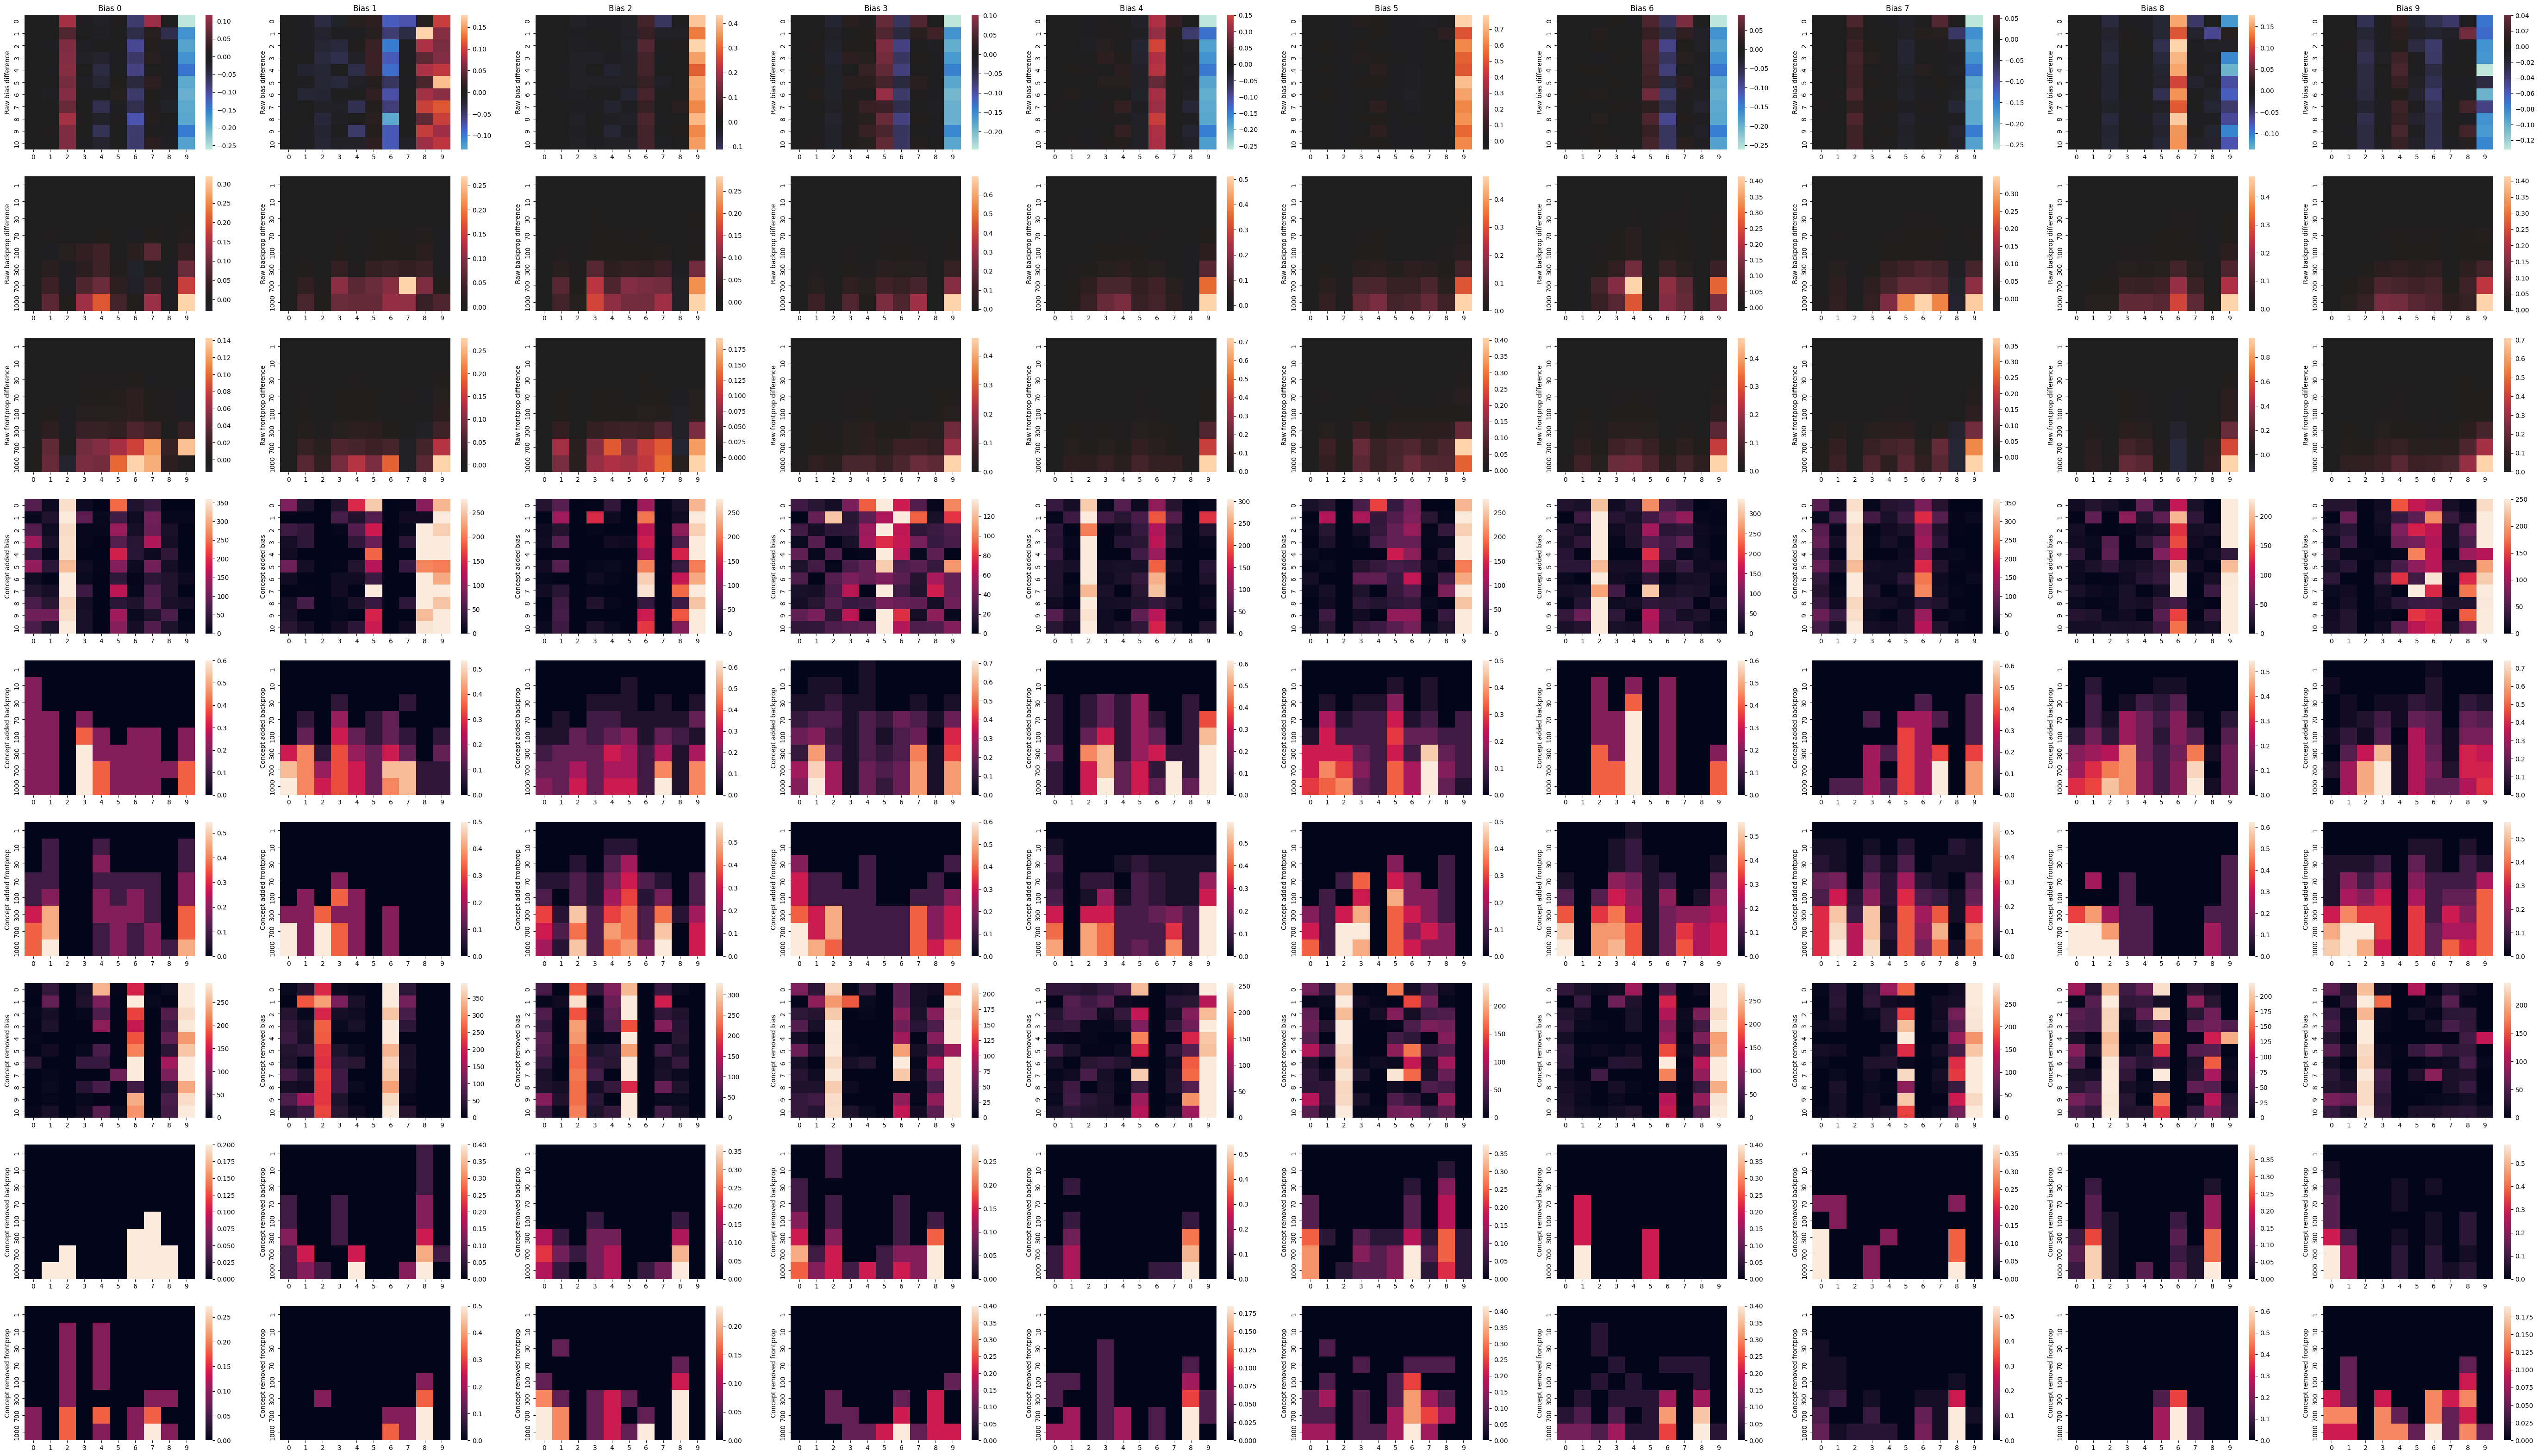

In [24]:
exp_id = 0
concept_id = 0
concept_amounts = [10, 30, 70, 100, 300, 500, 700]
amount_of_concept = concept_amounts[concept_id]
bias_range = range(10)
fig, axes = plt.subplots(9, len(bias_range), figsize=(70,40))
for index, studied_bias in enumerate(bias_range):
    with open(f"models/{exp_name}/bias_{exp_id}_{concept_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    with open(f"models/{exp_name}/concepts_{exp_id}_{concept_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    table = []
    for i in range(10):
        table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
    table.append(sum(table)/len(table))

    table1 = []
    for i in range(10):
        table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
    table1.append(sum(table1)/len(table1))

    table2 = []
    for i in range(10):
        table2.append(((bias_res[studied_bias][i][1] == 0) & (bias_res[studied_bias][i][0] > 0)).sum(axis=0))
    table2.append(sum(table2)/len(table2))

    neg_added = []
    neg_removed = []
    pos_added = []
    pos_removed = []
    raw_n_diff = []
    raw_p_diff = []
    for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
        table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
        neg_added.append(table_[0]/table_[2])
        neg_removed.append(table_[1]/table_[2])
        pos_added.append(table_[3]/table_[5])
        pos_removed.append(table_[4]/table_[5])
        raw_n_diff.append(table_[6])
        raw_p_diff.append(table_[7])

    sb.heatmap(table, center=0, annot=False, ax=axes[0][index])
    axes[0][index].set(ylabel="Raw bias difference", title=f"Bias {studied_bias}")
    sb.heatmap(raw_n_diff, center=0, ax=axes[1][index], yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000])
    axes[1][index].set(ylabel="Raw backprop difference")
    sb.heatmap(raw_p_diff, center=0, ax=axes[2][index], yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000])
    axes[2][index].set(ylabel="Raw frontprop difference")
    sb.heatmap(table1, vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[3][index])
    axes[3][index].set(ylabel="Concept added bias")
    sb.heatmap(table2, vmin=0, vmax=table2[-1].max(), annot=False, ax=axes[6][index])
    axes[6][index].set(ylabel="Concept removed bias")
    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(neg_added, vmin=0, vmax=neg_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[4][index])
    axes[4][index].set(ylabel="Concept added backprop")

    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(neg_removed, vmin=0, vmax=neg_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[7][index])
    axes[7][index].set(ylabel="Concept removed backprop")
    sb.heatmap(pos_added, vmin=0, vmax=pos_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[5][index])
    axes[5][index].set(ylabel="Concept added frontprop")
    sb.heatmap(pos_removed, vmin=0, vmax=pos_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[8][index])
    axes[8][index].set(ylabel="Concept removed frontprop")

    v_bias_identified = np.array(neg_added)
    v_bias_real = table1[-1]
    res = np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
    print(f"For {amount_of_concept} concept, the vector similarity is : {res}")

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[Text(0.5, 23.52222222222222, 'Number of backpropagation step'),
 Text(50.722222222222214, 0.5, 'Number of concept'),
 Text(0.5, 1.0, 'Similarity between real and identified bias encoding')]

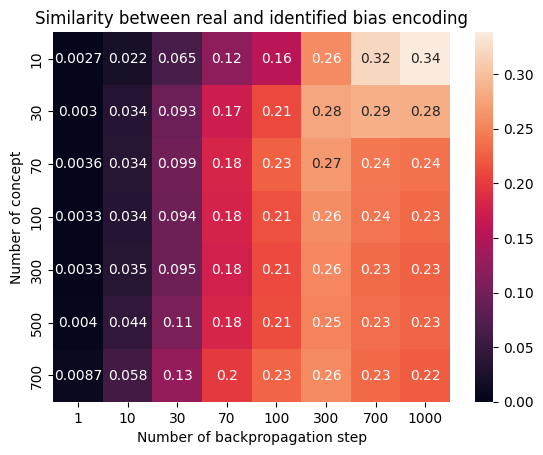

In [19]:
exp_range = range(5,10)
concept_range = range(0,7)
steps_amounts = [1, 10, 30, 70, 100, 300, 700, 1000]
concept_amounts = [10, 30, 70, 100, 300, 500, 700]

result = np.array([[0. for j in steps_amounts] for i in concept_range])
for exp_id in exp_range:
    temp_res = np.array([[0. for j in steps_amounts] for i in concept_range])
    for studied_bias in range(10):
        # fig, axes = plt.subplots(3, len(concept_range), figsize=(20,5))
        for index, concept_id in enumerate(concept_range):
            amount_of_concept = concept_amounts[concept_id]
            with open(f"models/{exp_name}/bias_{exp_id}_{concept_id}.pkl", "rb") as f:
                bias_res = pkl.load(f)
            with open(f"models/{exp_name}/concepts_{exp_id}_{concept_id}.pkl", "rb") as f:
                concept_res = pkl.load(f)
            table = []
            for i in range(10):
                table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
            table.append(sum(table)/len(table))
            # sb.heatmap(table[-1:], center=0, annot=False, ax=axes[0][index])

            table1 = []
            for i in range(10):
                table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
            table1.append(sum(table1)/len(table1))
            # sb.heatmap(table1[-1:], vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[1][index])

            truc = []
            for step_amount in steps_amounts:
                table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
                truc.append(table_[0])
            v_bias_identified = np.array(truc)
            v_bias_real = table1[-1]
            temp_res[index] += np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
            # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
            # sb.heatmap(truc, vmin=0, vmax=truc[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[2][index])
    result += (temp_res/10)
ax = sb.heatmap(result/len(exp_range), vmin=0, xticklabels=steps_amounts, yticklabels=concept_amounts, annot=True)
ax.set(xlabel="Number of backpropagation step", ylabel="Number of concept", title="Similarity between real and identified bias encoding")

In [111]:
from scipy.stats import kendalltau
a = np.array([3,2,1, 4, 9, 8, 6, 7, 5])
b = np.array([3,1,2,9, 8, 7, 5, 6, 4])
kendalltau(a, b)

SignificanceResult(statistic=np.float64(0.6666666666666666), pvalue=np.float64(0.012665343915343916))

In [112]:
kendalltau(np.argsort(a), np.argsort(b))

SignificanceResult(statistic=np.float64(0.5555555555555556), pvalue=np.float64(0.04461529982363316))

In [103]:
v_bias_identified[0].shape

(700,)

[Text(0.5, 23.52222222222222, 'Number of backpropagation step'),
 Text(50.722222222222214, 0.5, 'Number of concept'),
 Text(0.5, 1.0, 'Similarity between real and identified bias encoding')]

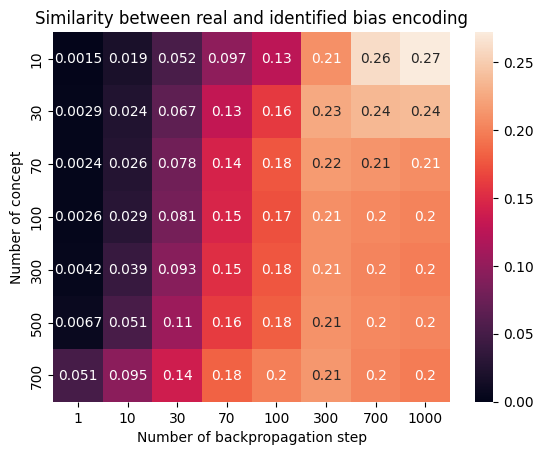

In [98]:
ax = sb.heatmap(result/len(exp_range), vmin=0, xticklabels=steps_amounts, yticklabels=concept_amounts, annot=True)
ax.set(xlabel="Number of backpropagation step", ylabel="Number of concept", title="Similarity between real and identified bias encoding")

<Axes: >

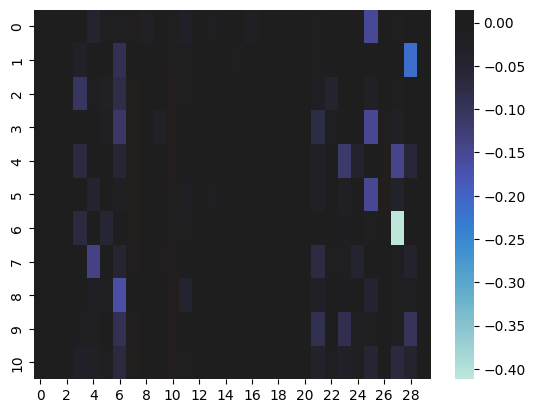

In [40]:
with open(f"models/{exp_name}/bias_{exp_id}_{1}.pkl", "rb") as f:
    bias_res = pkl.load(f)

table = []
for i in range(10):
    table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
table.append(sum(table)/len(table))
sb.heatmap(table, center=0, annot=False)

<Axes: >

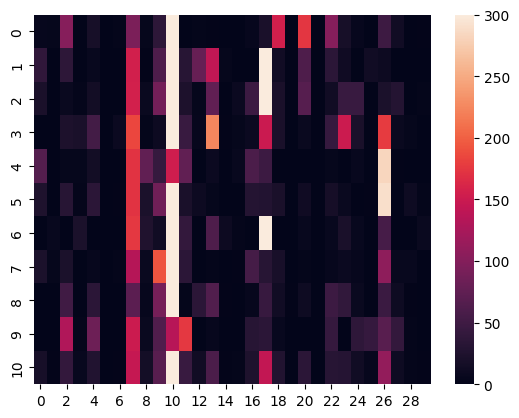

In [41]:
table1 = []
for i in range(10):
    table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
table1.append(sum(table1)/len(table1))
sb.heatmap(table1, vmin=0, vmax=300, annot=False)   

<Axes: >

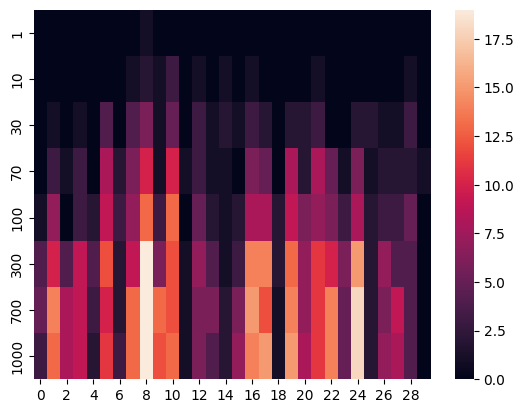

In [43]:
truc = []
for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
    table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
    truc.append(table_[0])
# table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap(truc, vmin=0, vmax=truc[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000])

<Axes: >

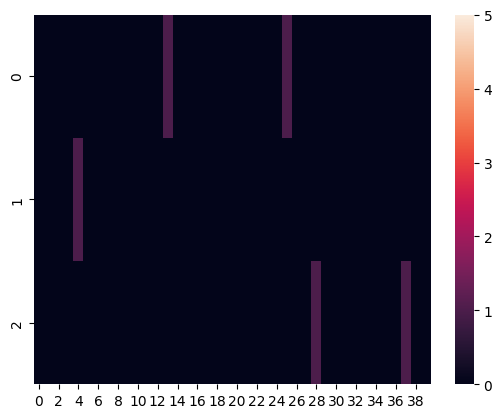

In [ ]:
table_ = cu.analyze_results(concept_res["concept_results"][10], studied_bias, 40)
table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap([table_[0], table_[1], table_[3]], vmin=0, vmax=5, annot=False)

<Axes: >

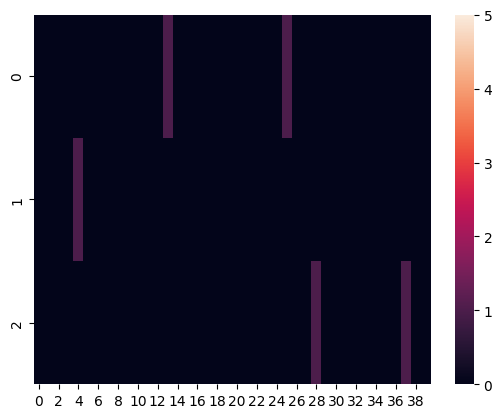

In [ ]:
table_ = cu.analyze_results(concept_res["concept_results"][10], studied_bias, 40)
table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap([table_[0], table_[1], table_[3]], vmin=0, vmax=5, annot=False)

In [30]:
table_

(array([0., 0., 2., 0., 2., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        1., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0.]),
 array([20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.]),
 array([14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,
        14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,
        14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,

In [17]:
data_path = os.getcwd() + "/data/MNIST"
device = "cuda"
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=res["batch_size"], data_label_correlation=res["test_correlation"], train=False)
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1 = nn.Sequential(nn.Linear(28*28*3, 512), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(512, 512), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(512, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.l1(x)
        x = self.l2(x)
        logits = self.l3(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    appearance_matrix = []
    correctness_matrix = None
    with torch.no_grad():
        for X, y, y_pred in dataloader:
            X, y, y_pred = X.to(device), y.to(device), y_pred.to(device)
            pred = model(X)
            if len(appearance_matrix)==0:
                size_y = len(pred[0])
                appearance_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                correctness_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            for i in range(size_y):
                for j in range(size_y):
                    appearance_matrix[i][j] += int(((y==i) & (y_pred==j)).sum())
                    correctness_matrix[i][j] += int((pred.argmax(1)[((y==i) & (y_pred==j))] == i).sum())
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_matrix = correctness_matrix/appearance_matrix
    return accuracy_matrix

assert(os.path.exists(f"models/{exp_name}/model_{exp_id}"))
model.load_state_dict(torch.load(f"models/{exp_name}/model_{exp_id}", weights_only=True))

base_acc = test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 78.1%, Avg loss: 0.659705 



In [19]:
import seaborn as sb

<Axes: >

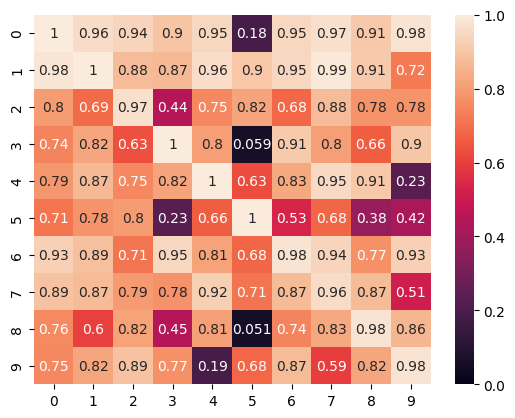

In [21]:
sb.heatmap(base_acc, vmin=0, vmax=1, annot=True)

<Axes: >

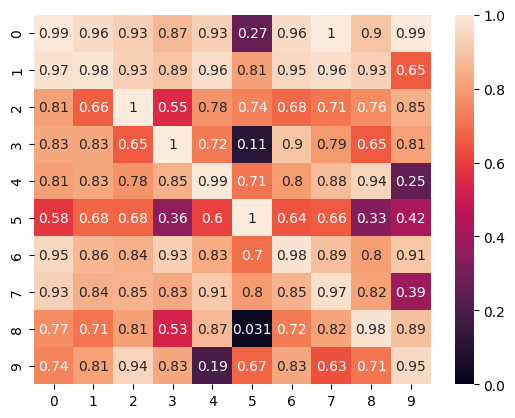

In [20]:
sb.heatmap(res["accuracy_matrix"], vmin=0, vmax=1, annot=True)